# 01 — Exploratory Data Analysis

This notebook inspects the Task 1 storm forecasting dataset and motivates the modelling choices used in the main repository.

Focus:
- event metadata and modality filtering
- storm-level structure and temporal coverage
- VIL-only task construction
- implications for model choice and evaluation

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data")
EVENTS_CSV = DATA_DIR / "events.csv"

assert EVENTS_CSV.exists(), f"Missing {EVENTS_CSV}. Run the data bootstrap first."
events = pd.read_csv(EVENTS_CSV)
print(events.shape)
events.head()

(4000, 11)


,id,img_type,event_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
0,S778114,ir069,Hail,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
1,S778114,ir107,Hail,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
2,S778114,lght,Hail,NaN,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3,S778114,vil,Hail,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
4,S778114,vis,Hail,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.94459,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


## Dataset context

The original dataset contains storm-centered observations across multiple modalities.  
For Task 1, the forecasting problem is restricted to **VIL (Vertically Integrated Liquid)** imagery:

- **input:** 12 past VIL frames
- **output:** 12 future VIL frames
- **cadence:** 5 minutes
- **spatial resolution:** 384 × 384

In [7]:
summary = pd.DataFrame(
    {
        "dtype": events.dtypes.astype(str),
        "n_unique": events.nunique(dropna=True),
        "missing_frac": events.isna().mean(),
    }
).sort_values("missing_frac", ascending=False)

summary.head(30)

,dtype,n_unique,missing_frac
start_utc,str,1173,0.2
img_type,str,5,0.0
id,str,800,0.0
event_type,str,8,0.0
llcrnrlat,float64,800,0.0
llcrnrlon,float64,798,0.0
urcrnrlat,float64,799,0.0
urcrnrlon,float64,798,0.0
proj,str,1,0.0
height_m,float64,1,0.0


In [8]:
cols = {c.lower(): c for c in events.columns}


def find_col(substrings):
    for s in substrings:
        for cl, orig in cols.items():
            if s in cl:
                return orig
    return None


col_id = find_col(["storm", "event", "id"])
col_time = find_col(["time", "start_utc", "timestamp", "date"])
col_lat = find_col(["lat"])
col_lon = find_col(["lon", "lng"])
col_type = find_col(["img_type", "type", "modality", "product"])

print("ID column:", col_id)
print("Time column:", col_time)
print("Lat column:", col_lat)
print("Lon column:", col_lon)
print("Type column:", col_type)

ID column: event_type
Time column: start_utc
Lat column: llcrnrlat
Lon column: llcrnrlon
Type column: img_type


## Metadata quality

The goal here is not exhaustive profiling, but checking whether the event metadata supports:
- storm-level grouping
- modality filtering
- basic temporal coverage checks
- simple spatial sanity checks

count                                3200
mean     2019-02-18 03:05:14.287500+00:00
min             2018-08-20 19:50:00+00:00
25%             2018-10-04 03:13:45+00:00
50%             2019-03-26 10:50:00+00:00
75%             2019-05-28 09:18:30+00:00
max             2019-07-28 17:45:00+00:00
Name: _time, dtype: object

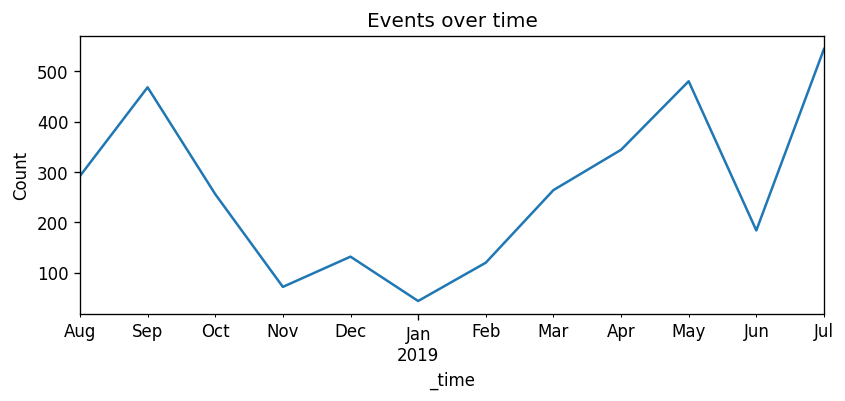

In [9]:
if col_time and col_time in events.columns:
    events["_time"] = pd.to_datetime(events[col_time], errors="coerce", utc=True)
    display(events["_time"].describe())

    by_month = events.dropna(subset=["_time"]).set_index("_time").resample("ME").size()
    ax = by_month.plot(figsize=(8, 3), title="Events over time")
    ax.set_ylabel("Count")
    plt.show()

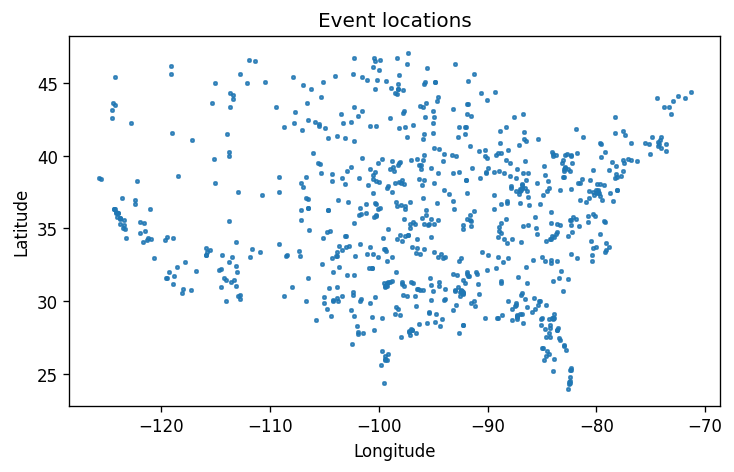

In [10]:
if col_lat and col_lon and col_lat in events.columns and col_lon in events.columns:
    plt.figure(figsize=(7, 4))
    plt.scatter(events[col_lon], events[col_lat], s=4, alpha=0.25)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Event locations")
    plt.show()

img_type
ir069    800
ir107    800
lght     800
vil      800
vis      800
Name: count, dtype: int64

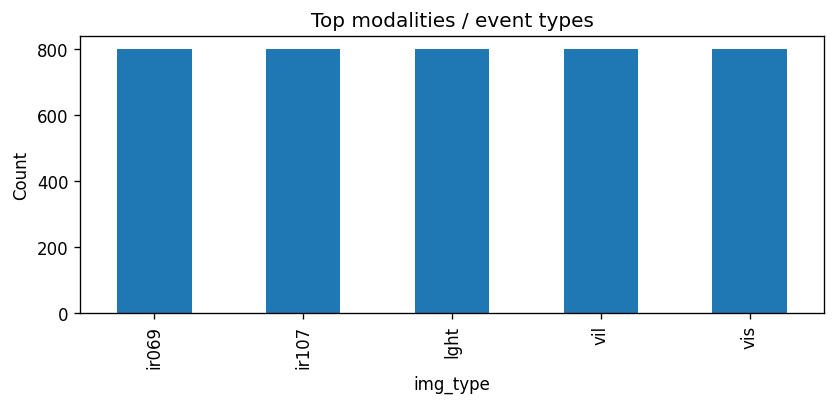

In [11]:
if col_type and col_type in events.columns:
    vc = events[col_type].value_counts(dropna=False)
    display(vc.head(20))

    plt.figure(figsize=(8, 3))
    vc.head(20).plot(kind="bar")
    plt.title("Top modalities / event types")
    plt.ylabel("Count")
    plt.show()

In [12]:
assert "img_type" in events.columns, "Expected img_type column for Task 1 filtering."
vil_df = events[events["img_type"] == "vil"].copy()

print("All rows:", len(events))
print("VIL rows:", len(vil_df))
print("Unique storm IDs:", vil_df["id"].nunique())
vil_df.head()

All rows: 4000
VIL rows: 800
Unique storm IDs: 800


,id,img_type,event_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m,_time
3,S778114,vil,Hail,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0,2018-08-20 19:50:00+00:00
8,S767475,vil,Thunderstorm Wind,2018-08-20 21:30:00+00:00,31.033963,-94.478926,34.278308,-90.155429,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0,2018-08-20 21:30:00+00:00
13,S771210,vil,Tornado,2018-08-20 21:40:00+00:00,43.590658,-115.365948,47.574769,-111.410627,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0,2018-08-20 21:40:00+00:00
18,S782022,vil,Flash Flood,2018-08-21 00:20:00+00:00,30.151476,-112.772184,34.032528,-109.229161,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0,2018-08-21 00:20:00+00:00
23,S769788,vil,Thunderstorm Wind,2018-08-21 17:10:00+00:00,38.392362,-81.327737,41.014591,-75.941131,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0,2018-08-21 17:10:00+00:00


## Task 1 dataset construction

Task 1 uses only VIL storms.  
Each unique event ID corresponds to a storm sequence, and the model constructs training samples by sliding a 12-frame input window over each 36-frame storm.

With:
- `Tin = 12`
- `Tout = 12`
- `stride = 1`

each storm yields **13 overlapping windows**.

In [13]:
n_storms = vil_df["id"].nunique()
tin, tout, stride, total_frames = 12, 12, 1, 36
n_windows_per_storm = (total_frames - tin - tout) // stride + 1
n_total_windows = n_storms * n_windows_per_storm

print("Storms:", n_storms)
print("Windows per storm:", n_windows_per_storm)
print("Total windows:", n_total_windows)

Storms: 800
Windows per storm: 13
Total windows: 10400


## Why the effective dataset size is still modest

Although the final run yields 10,400 training windows, these windows are **highly correlated**:

- only **800 unique storms**
- 13 windows per storm
- adjacent windows overlap heavily in time

So the effective amount of independent training signal is much closer to **hundreds of storms** than to a large-scale image-video dataset.

## Implications for model choice

This dataset structure strongly influenced model selection:

- the task needs **explicit temporal modelling** across a 12-step horizon
- the dataset is **too modest at the storm level** to justify jumping straight to very high-capacity diffusion or transformer-style approaches as the primary baseline
- the windows are heavily overlapping, so nominal sample count overstates effective diversity
- full-resolution `384 × 384` sequences also impose real compute constraints

For this reason, a **direct multi-output ConvLSTM-U-Net** was a sensible first model:
- ConvLSTM provides stateful temporal memory
- U-Net preserves multi-scale spatial structure
- direct forecasting avoids autoregressive error accumulation
- the architecture remains computationally feasible at full resolution

## EDA summary

The metadata analysis and task construction support the final modelling strategy:

- storm sequences are heterogeneous in duration, dynamics, and spatial footprint
- the forecasting horizon is long enough that autoregressive drift is a serious concern
- the dataset is structured, moderate in size, and not well matched to extremely data-hungry generative architectures
- a direct multi-output ConvLSTM-U-Net offers a strong balance of temporal memory, spatial detail, and computational practicality